# 🫘 PFA — Insuffisance Rénale Chronique (CKD)
### Pipeline ML complet · Dataset UCI
---

**Spécificités de ce dataset :**
- 26 colonnes (numériques + catégorielles)
- Nombreuses valeurs manquantes (jusqu'à 38% pour certaines colonnes)
- Valeurs parasites `ckd\t` dans la cible → nettoyage obligatoire
- Encodage des colonnes textuelles requis

## 1 · Importations

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
from imblearn.over_sampling import SMOTE

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost non installé — pip install xgboost")

RANDOM_STATE = 42
print("✓ Importations OK")

✓ Importations OK


## 2 · Chargement & Exploration

In [2]:
df = pd.read_csv('kidney_disease.csv', na_values=['?', '', ' ', '\t'])
print(f"Shape : {df.shape}")
display(df.head())

print("\nTypes de données :")
display(df.dtypes.value_counts())

print("\nValeurs manquantes (%) :")
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
display(missing[missing > 0].round(1))

Shape : (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd



Types de données :


str        14
float64    11
int64       1
Name: count, dtype: int64


Valeurs manquantes (%) :


rbc      38.0
rc       32.5
wc       26.2
pot      22.0
sod      21.8
pcv      17.5
pc       16.2
hemo     13.0
su       12.2
sg       11.8
al       11.5
bgr      11.0
bu        4.8
sc        4.2
bp        3.0
age       2.2
pcc       1.0
ba        1.0
dm        0.5
htn       0.5
cad       0.5
appet     0.2
ane       0.2
pe        0.2
dtype: float64

Valeurs brutes de la cible 'classification' :
classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

⚠️  Présence de 'ckd\t' → nettoyage nécessaire !


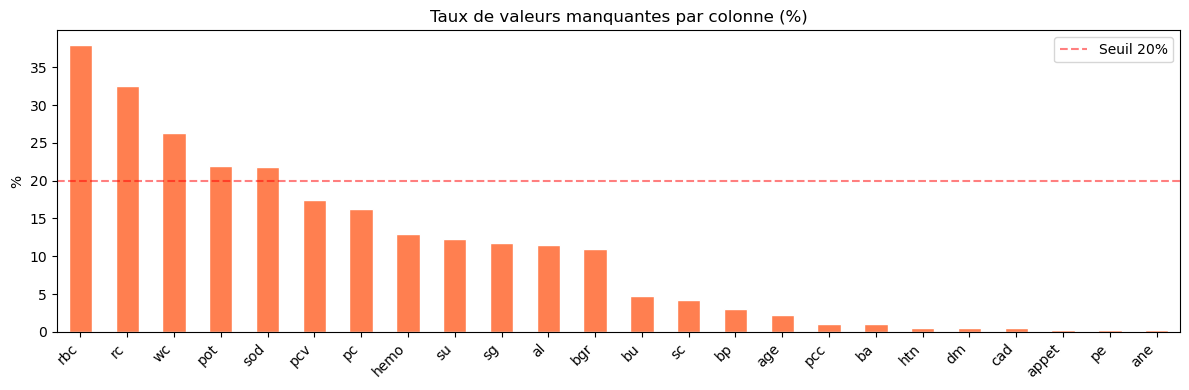

In [3]:
# Distribution de la cible AVANT nettoyage
print("Valeurs brutes de la cible 'classification' :")
print(df['classification'].value_counts())
print("\n⚠️  Présence de 'ckd\\t' → nettoyage nécessaire !")

# Visualisation NaN par colonne
fig, ax = plt.subplots(figsize=(12, 4))
missing_pct = df.isnull().sum() / len(df) * 100
missing_pct[missing_pct > 0].sort_values(ascending=False).plot.bar(ax=ax, color='coral', edgecolor='white')
ax.set_title('Taux de valeurs manquantes par colonne (%)')
ax.set_ylabel('%')
ax.axhline(20, color='red', linestyle='--', alpha=0.5, label='Seuil 20%')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

## 3 · Nettoyage & Prétraitement

> **Étapes spécifiques CKD :**
> 1. Supprimer la colonne `id` (identifiant non prédictif)
> 2. Nettoyer les valeurs parasites dans la cible (`ckd\t` → `ckd`)
> 3. Encoder les colonnes catégorielles
> 4. Imputer les valeurs manquantes
> 5. SMOTE

In [4]:
df_clean = df.copy()

# --- 3.1 Supprimer id ---
df_clean = df_clean.drop(columns=['id'], errors='ignore')

# --- 3.2 Nettoyer la cible (ckd\t → ckd) ---
df_clean['classification'] = df_clean['classification'].str.strip()
print("Cible après nettoyage :")
print(df_clean['classification'].value_counts())

# --- 3.3 Encoder la cible : ckd=1, notckd=0 ---
df_clean['target'] = (df_clean['classification'] == 'ckd').astype(int)
df_clean = df_clean.drop(columns=['classification'])
print(f"\nCible encodée : {df_clean['target'].value_counts().to_dict()}")

# --- 3.4 Identifier les colonnes catégorielles ---
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
num_cols = df_clean.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'target']
print(f"\nColonnes catégorielles : {cat_cols}")
print(f"Colonnes numériques    : {num_cols}")

Cible après nettoyage :
classification
ckd       250
notckd    150
Name: count, dtype: int64

Cible encodée : {1: 250, 0: 150}

Colonnes catégorielles : ['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
Colonnes numériques    : ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']


In [5]:
# --- 3.5 Encodage des colonnes catégorielles ---
# Valeurs attendues : yes/no, present/notpresent, normal/abnormal, good/poor, ckd/notckd
le = LabelEncoder()
for col in cat_cols:
    # Imputer les NaN de la catégorielle par le mode avant encodage
    mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'unknown'
    df_clean[col] = df_clean[col].fillna(mode_val)
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print("Colonnes catégorielles encodées ✓")
print("\nAperçu après encodage :")
display(df_clean.head(3))

Colonnes catégorielles encodées ✓

Aperçu après encodage :


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,target
0,48.0,80.0,1.02,1.0,0.0,1,1,0,0,121.0,...,32,72,34,1,4,1,0,0,0,1
1,7.0,50.0,1.02,4.0,0.0,1,1,0,0,NaN,...,26,56,34,0,3,1,0,0,0,1
2,62.0,80.0,1.01,2.0,3.0,1,1,0,0,423.0,...,19,70,34,0,4,1,1,0,1,1


In [6]:
# --- 3.6 Séparation features / cible + Imputation ---
X = df_clean.drop('target', axis=1)
y = df_clean['target']

# Forcer toutes les colonnes en float (au cas où certaines restent en object)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

feature_names = X.columns.tolist()
print(f"Features : {feature_names}")
print(f"Shape X : {X.shape}")

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f"Valeurs manquantes après imputation : {X_imp.isnull().sum().sum()}")

# --- 3.7 Split stratifié ---
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")
print(f"Proportion cible train : {y_train.mean():.3f} | test : {y_test.mean():.3f}")

# --- 3.8 Standardisation ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# --- 3.9 SMOTE ---
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)
print(f"\nAprès SMOTE → Total: {len(y_train_bal)} | CKD: {(y_train_bal==1).sum()} | NotCKD: {(y_train_bal==0).sum()}")

Features : ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
Shape X : (400, 24)
Valeurs manquantes après imputation : 0
Train : 320 | Test : 80
Proportion cible train : 0.625 | test : 0.625

Après SMOTE → Total: 400 | CKD: 200 | NotCKD: 200


## 4 · Entraînement des Modèles

In [7]:
models = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Arbre de Décision":     DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest":         RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM":                   SVC(probability=True, random_state=RANDOM_STATE),
    "Gradient Boosting":     GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}
if HAS_XGB:
    models["XGBoost"] = XGBClassifier(n_estimators=200, use_label_encoder=False,
                                       eval_metric='logloss', random_state=RANDOM_STATE)

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred    = model.predict(X_test_sc)
    y_proba   = model.predict_proba(X_test_sc)[:, 1]
    cv_scores = cross_val_score(model, X_train_bal, y_train_bal, cv=cv, scoring='roc_auc')
    results[name] = {
        'Accuracy':      accuracy_score(y_test, y_pred),
        'Precision':     precision_score(y_test, y_pred, zero_division=0),
        'Recall':        recall_score(y_test, y_pred),
        'F1-score':      f1_score(y_test, y_pred),
        'AUC-ROC':       roc_auc_score(y_test, y_proba),
        'CV-AUC (mean)': cv_scores.mean(),
        'CV-AUC (std)':  cv_scores.std(),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        '_model': model, '_y_proba': y_proba,
    }
    print(f"  {name:<25} Acc={results[name]['Accuracy']:.3f} | F1={results[name]['F1-score']:.3f} | AUC={results[name]['AUC-ROC']:.3f} | CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}")

  Régression Logistique     Acc=0.988 | F1=0.990 | AUC=1.000 | CV=1.000±0.000
  Arbre de Décision         Acc=0.975 | F1=0.980 | AUC=0.980 | CV=0.972±0.017
  Random Forest             Acc=1.000 | F1=1.000 | AUC=1.000 | CV=1.000±0.000
  SVM                       Acc=0.975 | F1=0.980 | AUC=1.000 | CV=1.000±0.000
  Gradient Boosting         Acc=0.988 | F1=0.990 | AUC=1.000 | CV=1.000±0.000
  XGBoost                   Acc=0.988 | F1=0.990 | AUC=0.999 | CV=0.998±0.003


## 5 · Évaluation & Visualisations

In [8]:
metrics_df = pd.DataFrame({k: {m: v for m, v in vv.items()
                                if not m.startswith('_') and m != 'Confusion Matrix'}
                           for k, vv in results.items()}).T
display(metrics_df.style.highlight_max(axis=0, color='#d4f0c0').format("{:.4f}"))
best_model_name = metrics_df['AUC-ROC'].idxmax()
print(f"\n Meilleur modèle : {best_model_name}")

,Accuracy,Precision,Recall,F1-score,AUC-ROC,CV-AUC (mean),CV-AUC (std)
Régression Logistique,0.9875,1.0000,0.9800,0.9899,1.0000,0.9999,0.0002
Arbre de Décision,0.9750,1.0000,0.9600,0.9796,0.9800,0.9725,0.0166
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
SVM,0.9750,1.0000,0.9600,0.9796,1.0000,0.9999,0.0002
Gradient Boosting,0.9875,1.0000,0.9800,0.9899,1.0000,0.9999,0.0002
XGBoost,0.9875,1.0000,0.9800,0.9899,0.9993,0.9984,0.0029



 Meilleur modèle : Régression Logistique


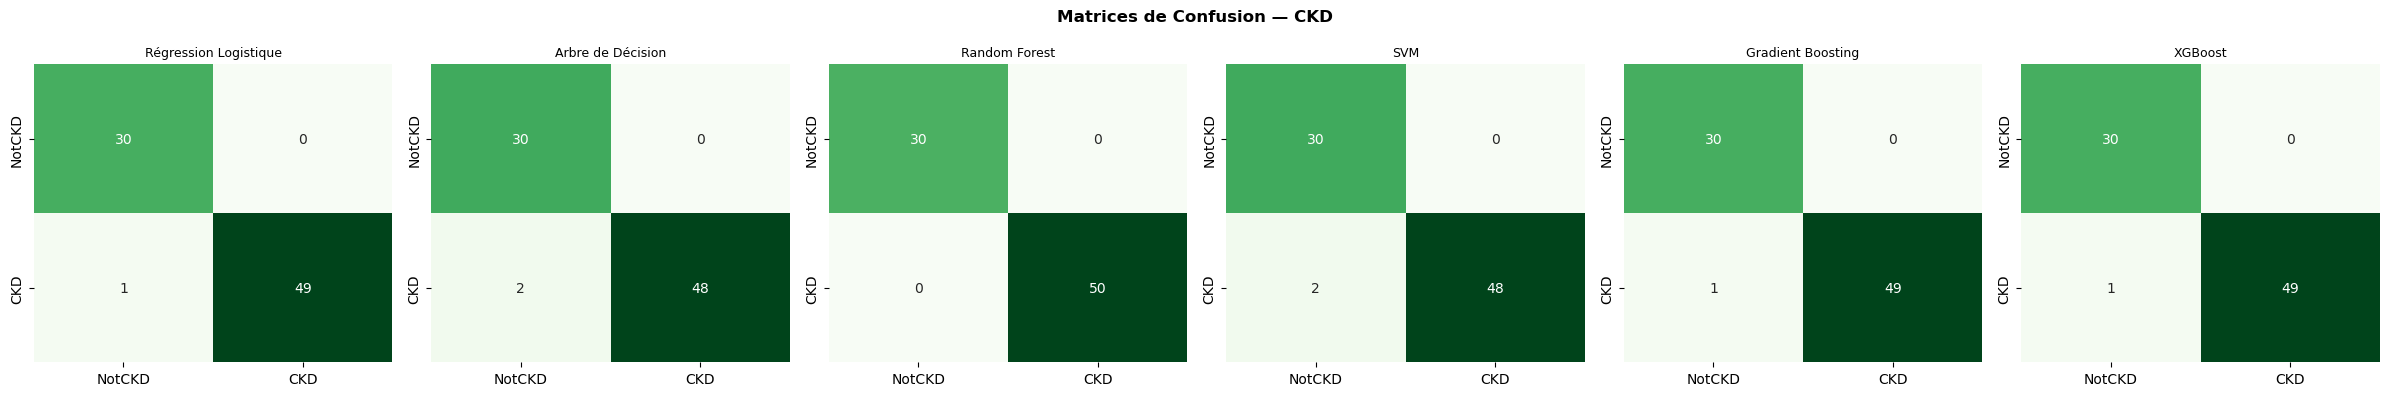

In [9]:
n = len(models)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for i, (name, res) in enumerate(results.items()):
    sns.heatmap(res['Confusion Matrix'], annot=True, fmt='d', ax=axes[i], cmap='Greens',
                cbar=False, xticklabels=['NotCKD','CKD'], yticklabels=['NotCKD','CKD'])
    axes[i].set_title(name, fontsize=9)
plt.suptitle('Matrices de Confusion — CKD', fontweight='bold')
plt.tight_layout(); plt.show()

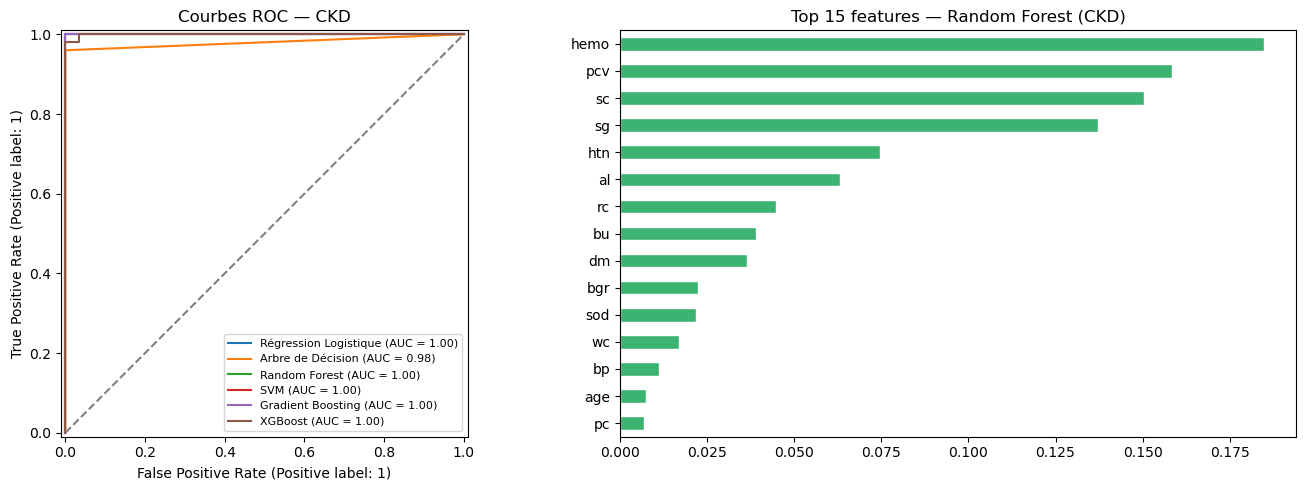

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbes ROC
for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res['_y_proba'], name=name, ax=axes[0])
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_title('Courbes ROC — CKD')
axes[0].legend(loc='lower right', fontsize=8)

# Feature importance Random Forest
rf = results['Random Forest']['_model']
feat_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True).tail(15)
feat_imp.plot.barh(ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Top 15 features — Random Forest (CKD)')
plt.tight_layout(); plt.show()

## 6 · Sauvegarde

In [11]:
best_model = results[best_model_name]['_model']
joblib.dump(best_model, 'model_ckd.pkl')
joblib.dump(scaler,     'scaler_ckd.pkl')
joblib.dump(imputer,    'imputer_ckd.pkl')
print(f"✓ Modèle '{best_model_name}' sauvegardé → model_ckd.pkl")

y_pred_best = best_model.predict(X_test_sc)
print(classification_report(y_test, y_pred_best, target_names=['NotCKD','CKD']))

✓ Modèle 'Régression Logistique' sauvegardé → model_ckd.pkl
              precision    recall  f1-score   support

      NotCKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



## 7 · Interprétabilité — Analyse des features les plus importantes

> Les features les plus importantes pour l'IRC sont généralement :
> - `hemo` (hémoglobine), `sc` (créatinine sérique), `sg` (densité urinaire), `al` (albumine)
> Ces features biologiques sont cohérentes avec la physiopathologie de l'IRC.

In [12]:
rf = results['Random Forest']['_model']
feat_series = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 10 features les plus prédictives pour l'IRC :")
print(feat_series.head(10).to_string())
print("\nInterprétation médicale :")
print("  hemo (hémoglobine)   → L'anémie est un marqueur direct de l'IRC")
print("  sc (créatinine sérum)→ Marqueur de filtration glomérulaire, critère diagnostic IRC")
print("  sg (densité urinaire)→ Reflète la capacité de concentration du rein")
print("  al (albumine urine)  → La protéinurie est le premier signe d'atteinte rénale")

Top 10 features les plus prédictives pour l'IRC :
hemo    0.184884
pcv     0.158468
sc      0.150504
sg      0.137152
htn     0.074769
al      0.063282
rc      0.044764
bu      0.038920
dm      0.036356
bgr     0.022400

Interprétation médicale :
  hemo (hémoglobine)   → L'anémie est un marqueur direct de l'IRC
  sc (créatinine sérum)→ Marqueur de filtration glomérulaire, critère diagnostic IRC
  sg (densité urinaire)→ Reflète la capacité de concentration du rein
  al (albumine urine)  → La protéinurie est le premier signe d'atteinte rénale
